# Choosing which MD conformers to dock

Part B of the torsion work. [`ab_torsions.ipynb`](ab_torsions.ipynb) measured how far the bound
and unbound crystal structures differ in torsion space; this notebook uses the same features to
decide **which frames of a trajectory become the ensemble handed to HADDOCK3**.

## What is wrong with the current selection

The workflow clusters with `gmx cluster` on the `Loop_CA` group. Three specific problems:

* **Geometric, not kinetic.** An RMSD cutoff splits a single broad basin into several clusters
  and merges conformers separated by a real barrier. The representatives are not distinct
  conformers, they are RMSD neighbourhoods.
* **Blind to side chains.** `Loop_CA` is C-alpha only, and section 5 of `ab_torsions.ipynb` found
  `chi1` state changing about four times as often as backbone basin. The axis that varies most on
  binding is the one C-alpha clustering cannot see.
* **A cutoff nobody can defend.** It is currently `0.01` nm, which is a no-op.

## What replaces it

`sin`/`cos` of CDR `phi`/`psi` **plus interface `chi1`** -> TICA -> k-means microstates -> MSM ->
PCCA+ metastable states, one representative per state, ordered by stationary population. The
ensemble size then comes from a timescale gap rather than a cutoff, each member carries a
population, and because the features are internal coordinates the selection no longer depends on
the framework fit or the PBC treatment at all.

## How it gets scored rather than argued about

The bound structure is known for every benchmark case, so define

> `d_min(N)` = the smallest **CDR C-alpha RMSD to the bound antibody**, measured after
> superposing on the Fv framework C-alpha, over the `N` selected members.

That is exactly `ab_rmsds.ipynb`'s `('cdr_all', 'ca', 'fv_fw_ca')` quantity, evaluated on a
trajectory frame instead of the unbound crystal structure, so the numbers are directly comparable
to its `cdr_ca_fw_rmsd` column. Lower is better. Plotted against `N` it compares selection
strategies on equal terms, and it has two natural reference lines: the **unbound crystal
structure**, which is what docking without an ensemble would use, and the incumbent
**gromos/C-alpha** representatives.

`N` is not free either. HADDOCK3's rigidbody module computes

    sampling_factor = int(sampling / len(models_to_dock))

so 200 orientations over 10 conformers is 20 each. Every member added buys conformational
coverage and costs orientational sampling.

## What is measured here and what is only demonstrated

The trajectory in the repository is a **6-frame test run**. Every kinetic quantity below --
timescales, populations, metastable states -- is therefore meaningless *on that trajectory*, and
the notebook says so where it happens instead of printing numbers that look real.

So correctness is established two other ways, in section 2, before anything else runs:

1. **On a synthetic system whose answer is known by construction** -- torsions that jump between
   three well-separated states plus forty fast nuisance angles. The pipeline must recover three
   states and pick one frame from each.
2. **Against the other two notebooks.** The crystal-structure featurisation must reproduce
   `ab_torsions_imgt.csv` angle for angle, and the coverage metric must reproduce
   `ab_rmsds.ipynb`'s `cdr_ca_fw_rmsd` for the unbound structure. Both are exact tests, not
   correlations.

When the production trajectories land, sections 3 to 6 produce the real answer with no code
changes -- only `TRAJ` and the lag time need revisiting.

In [2]:
import os
import warnings
from pathlib import Path

# Same cwd handling as ab_torsions.ipynb: relative paths everywhere, so the kernel has to sit in
# the notebooks directory.
NB_DIR = Path.cwd()
if not (NB_DIR / 'data' / '0_base').is_dir():
    alt = NB_DIR / 'biobb_wf_antibody' / 'notebooks'
    if (alt / 'data' / '0_base').is_dir():
        os.chdir(alt)
        NB_DIR = Path.cwd()
        print(f'chdir -> {NB_DIR}')
    else:
        raise RuntimeError(f'kernel cwd {NB_DIR} does not contain data/0_base')

import matplotlib.pyplot as plt
import MDAnalysis as mda
import numpy as np
import pandas as pd
import seaborn as sns

import ab_common as ab
import ab_ensemble as ae

from biobb_common import biobb_global_properties

biobb_global_properties.update({
    'out_log_path': 'log/log.out',
    'err_log_path': 'log/log.err',
    'remove_tmp': True,
    'can_write_console_log': False,
})

# The case and the trajectory. Deliberately *not* imported from `variables.py`: that module
# parses `python/workflow.yml` at import time, so an unrelated edit to the workflow configuration
# takes this notebook down with it. The file layout it produces is stable, so the paths are
# derived from the case index instead.
CASE = 14
MD_DIR = Path('data') / f'case_{CASE}' / '2_MD'
TRAJ = (MD_DIR / 'antibody_md_dry.gro', MD_DIR / 'antibody_imaged_traj_fw.trr')
GROMOS_CLUSTERS = MD_DIR / 'antibody_clusters.pdb'      # the incumbent selection
for path in (*TRAJ, GROMOS_CLUSTERS):
    if not path.is_file():
        raise FileNotFoundError(f'{path} -- run the MD section of biobb_antibody.ipynb first')

OUT = Path('data') / 'ensemble'
RES = OUT / 'results'
FIG = OUT / 'figures'
TORSION_RES = Path('data') / 'torsions' / 'results'    # written by ab_torsions.ipynb
RMSD_RES = Path('data') / 'rmsds' / 'results'          # written by ab_rmsds.ipynb
for d in (RES, FIG, Path('log')):
    d.mkdir(parents=True, exist_ok=True)

sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.width', 200, 'display.max_columns', 60)
warnings.filterwarnings('ignore', category=UserWarning, module='Bio.PDB')

print('cwd        :', NB_DIR)
print('case       :', CASE)
print('structure  :', TRAJ[0])
print('trajectory :', TRAJ[1])
print('output dir :', OUT)

cwd        : /home/rchaves/repo/biobb/biobb_wf_antibody/biobb_wf_antibody/notebooks
case       : 14
structure  : data/case_14/2_MD/antibody_md_dry.gro
trajectory : data/case_14/2_MD/antibody_imaged_traj_fw.trr
output dir : data/ensemble


## 1. The trajectory, and joining it to the benchmark case

Three things have to line up before any of this means anything: the MD system has to be the same
antibody the benchmark case describes, its residues have to be identified with the IMGT positions
of that case, and the torsions computed from the trajectory have to be the *same* torsions
`ab_torsions.ipynb` computed from the crystal structures.

The first two are done by `ab_ensemble.md_prep_mapping`, which matches the MD sequence against the
prepared unbound antibody. It has to: `pdb2gmx` merges both chains into one segment and drops the
chain IDs, so the chain *order* in the MD file is not recoverable from the file itself. A
mismatch raises rather than silently shifting every residue.

The third is why the angle tables and `dihedral()` live in `ab_common` and are imported by both
notebooks. Section 2 tests that this actually held.

In [3]:
cases, tables = ab.build_cases(verbose=False)
ctx = cases[CASE]
bench = ab.BENCHMARK[ctx['unb_code']]
print(f'case {CASE}: bound {ctx["ref"]}  unbound {ctx["unb"]}  '
      f'({bench[1]}, published I-RMSD {bench[2]} A)')

u = mda.Universe(str(TRAJ[0]), str(TRAJ[1]))
mapping = ae.md_prep_mapping(u, ctx['paths']['unb_ab'])
n_frames = len(u.trajectory)
print(f'trajectory : {n_frames} frames, dt = {u.trajectory.dt} ps, '
      f'{u.atoms.n_atoms} atoms')
print(f'mapping    : chain order {mapping["chain_order"]}, '
      f'{len(mapping["map"])} of {mapping["n_res"]} residues identified')

spec = ae.feature_spec(ctx, u, mapping, iface='interface10', use_chi1=True)
angles = ae.featurize(u, spec)
X = ae.sincos(angles)
print(f'feature vector: {X.shape[1]} sin/cos components from {X.shape[0]} frames')
display(spec.groupby(['region', 'angle']).size().unstack(fill_value=0))

MEANINGFUL = n_frames >= ae.MIN_FRAMES_MEANINGFUL
if not MEANINGFUL:
    print(f'\n{"=" * 92}\nDEMONSTRATION ONLY: {n_frames} frames is far below the '
          f'{ae.MIN_FRAMES_MEANINGFUL} this analysis needs.\nEvery kinetic number below (implied '
          f'timescales, populations, metastable states) is noise.\nThe code paths run so they can '
          f'be checked; the conclusions wait for the production run.\n{"=" * 92}')

case 14: bound 3L5W_LH:I  unbound 3L7E_LH  (medium, published I-RMSD 0.48 A)
trajectory : 6 frames, dt = 2.0 ps, 6477 atoms
mapping    : chain order ('L', 'H'), 429 of 429 residues identified
featurised 6 frames x 140 torsions (96 CDR backbone, 44 interface chi1)
feature vector: 280 sin/cos components from 6 frames

DEMONSTRATION ONLY: 6 frames is far below the 500 this analysis needs.
Every kinetic number below (implied timescales, populations, metastable states) is noise.
The code paths run so they can be checked; the conclusions wait for the production run.


angle,chi1,phi,psi
region,,,
CDR1,10,16,16
CDR2,8,10,10
CDR3,15,22,22
FR,11,0,0


## 2. Verification

Three checks, run before anything is concluded. The first two are exact and tie this notebook to
the other two; the third tests the selection pipeline end to end on data whose answer is known.

In [4]:
# --- Check 1: the crystal featurisation agrees with ab_torsions.ipynb ------------------------
# featurize_structure() has to place a crystal structure in exactly the feature space the
# trajectory occupies, or the projection in section 6 compares two different things. The angles it
# produces must match ab_torsions_imgt.csv, which was itself checked against mdtraj.
A_bound, miss_b = ae.featurize_structure(ctx, spec, 'ref')
A_unbound, miss_u = ae.featurize_structure(ctx, spec, 'unb')

tor = pd.read_csv(TORSION_RES / 'ab_torsions_imgt.csv', keep_default_na=False, na_values=[''])
tor = tor[tor.case_idx == CASE].copy()
tor['imgt_icode'] = tor.imgt_icode.fillna('')
key = tor.set_index(['chain_type', 'imgt_num', 'imgt_icode', 'angle'])

worst_b = worst_u = 0.0
n_checked = 0
for i, row in enumerate(spec.itertuples()):
    k = (row.chain_type, row.imgt_num, row.imgt_icode, row.angle)
    if k not in key.index:
        continue
    ref_row = key.loc[k]
    if getattr(ref_row, 'ndim', 1) > 1:
        ref_row = ref_row.iloc[0]
    worst_b = max(worst_b, abs(float(ab.wrap(A_bound[0, i] - ref_row['val_bound']))))
    worst_u = max(worst_u, abs(float(ab.wrap(A_unbound[0, i] - ref_row['val_unbound']))))
    n_checked += 1

print('Check 1  crystal featurisation vs ab_torsions_imgt.csv')
print(f'  {n_checked} of {len(spec)} torsions cross-checked, '
      f'{miss_b} undefined in the bound structure, {miss_u} in the unbound one')
print(f'  worst disagreement: bound {worst_b:.1e} deg, unbound {worst_u:.1e} deg')
assert n_checked == len(spec), 'some features have no counterpart in the torsion table'
assert max(worst_b, worst_u) < 1e-8

Check 1  crystal featurisation vs ab_torsions_imgt.csv
  140 of 140 torsions cross-checked, 0 undefined in the bound structure, 0 in the unbound one
  worst disagreement: bound 2.8e-14 deg, unbound 2.8e-14 deg


In [5]:
# --- Check 2: the coverage metric agrees with ab_rmsds.ipynb ---------------------------------
# cdr_rmsd_to_bound() reimplements ab_rmsds' `fv_fw_ca` scheme against a trajectory frame. Fed the
# unbound crystal structure instead of a frame, it must return that notebook's number for this
# case -- which is also the reference line the whole scoreboard is measured against, since it is
# what docking with no ensemble at all would use.
reference = ae.bound_reference(ctx, mapping)
d_unbound = float(ae.cdr_rmsd_to_bound(mda.Universe(str(ctx['paths']['unb_ab'])), reference)[0])

rmsd_long = pd.read_csv(RMSD_RES / 'ab_rmsds_long.csv')
published = float(rmsd_long[(rmsd_long.case_idx == CASE) & (rmsd_long.extent == 'cdr_all')
                            & (rmsd_long.atom_set == 'ca')
                            & (rmsd_long.scheme == 'fv_fw_ca')]['rmsd'].iloc[0])

print('Check 2  coverage metric vs ab_rmsds.ipynb')
print(f'  framework CA superposed: {len(reference["fw_bound"])}, CDR CA measured: '
      f'{len(reference["cdr_bound"])}')
print(f'  unbound crystal, this notebook : {d_unbound:.4f} A')
print(f'  unbound crystal, ab_rmsds.ipynb: {published:.4f} A')
assert abs(d_unbound - published) < 1e-3, 'the two notebooks disagree about the same quantity'

Check 2  coverage metric vs ab_rmsds.ipynb
  framework CA superposed: 180, CDR CA measured: 48
  unbound crystal, this notebook : 0.5089 A
  unbound crystal, ab_rmsds.ipynb: 0.5089 A


In [6]:
# --- Check 3: the selection pipeline, on a system whose states are known -----------------------
# Four torsions jump together between three well-separated values and stay for ~400 frames; forty
# more are fast noise around fixed values, three times as wide as the slow ones. That is the
# situation the whole design rests on: the variance is dominated by angles that carry no
# information, and only a time-lagged method ignores them. TICA must find two slow modes (three
# states -> two), PCCA+ must recover the three states, and the selection must pick one frame from
# each. A variance-based method (dPCA) on the same data would lock onto the noise.
syn_angles, syn_truth = ae.synthetic_torsions(n_frames=6000, n_states=3, n_slow=4, n_fast=40,
                                             dwell=400, noise=12.0, seed=0)
syn_X = ae.sincos(syn_angles)
_m, syn_Y, syn_info = ae.tica(syn_X, lag=20, dim=2)
syn_labels, _c, syn_micro = ae.discretise(syn_Y, 100)
syn_macro = ae.macrostates(syn_labels, lag=20, n_macro=3)

print('Check 3  synthetic system: 3 states by construction')
print(f'  TICA timescales (frames): {np.round(syn_info["timescales"], 1)}')
assert 'error' not in syn_macro, syn_macro.get('error')
purity = ae.state_purity(syn_macro['assign'], syn_truth)
picked = ae.select_pcca(syn_Y, syn_macro, 3)
print(f'  microstates {syn_micro} -> macrostates {syn_macro["n_macro"]}')
print(f'  populations       : {np.round(syn_macro["populations"], 3)}')
print(f'  true populations  : {np.round(np.bincount(syn_truth) / len(syn_truth), 3)}')
print(f'  state purity vs truth: {purity:.3f}')
print(f'  selected frames {picked} -> true states {syn_truth[picked]} '
      f'({len(set(syn_truth[picked]))} of 3 distinct)')
assert purity > 0.95, 'the metastable decomposition does not recover the known states'
assert len(set(syn_truth[picked])) == 3, 'the selection missed a state'

# and the contrast that motivates using TICA rather than plain dPCA on the same features
from sklearn.decomposition import PCA
dpca_Y = PCA(n_components=2).fit_transform(syn_X)
dpca_labels, _c2, _n2 = ae.discretise(dpca_Y, 100)
dpca_picked = ae.select_kmedoid(dpca_Y, 3)
print(f'  for contrast, dPCA (variance, no lag) on the same features picks true states '
      f'{syn_truth[dpca_picked]} -> {len(set(syn_truth[dpca_picked]))} of 3 distinct')

Check 3  synthetic system: 3 states by construction
  TICA timescales (frames): [314.3  89.5]
  microstates 100 -> macrostates 3
  populations       : [0.059 0.419 0.522]
  true populations  : [0.066 0.468 0.466]
  state purity vs truth: 1.000
  selected frames [3243, 4567, 4857] -> true states [1 2 0] (3 of 3 distinct)
  for contrast, dPCA (variance, no lag) on the same features picks true states [1 2 1] -> 2 of 3 distinct


## 3. TICA on the trajectory

The lag time is the one real choice. Too short and TICA reports the fast relaxation inside a
basin; too long and the slow processes have already decorrelated and their timescales collapse.
The standard test is to plot the implied timescales against the lag and use a value where they
have levelled off -- a plateau means the estimate no longer depends on the choice.

Kept dimensions come from the same table. Three metastable states produce two slow modes, four
produce three, so a gap in the timescale spectrum is a more honest dimension selector than a
cumulative-variance cutoff: on the synthetic system above, `var_cutoff=0.95` kept 38 of 44
components while the timescales showed the gap after 2.

In [8]:
# Lags to scan, and the lag actually used. On a production trajectory pick LAG from the plateau;
# on a 6-frame test run there is nothing to plateau and the scan exists only to run.
LAGS = [lag for lag in (1, 2, 5, 10, 20, 50, 100, 200) if lag < max(2, n_frames - 1)]
LAG = LAGS[-1] if MEANINGFUL else 1
N_TICS = 2

its = ae.implied_timescales(X, LAGS, n_ts=4)
display(its.round(2))

tica_model, Y, tica_info = ae.tica(X, lag=LAG, dim=min(N_TICS, X.shape[1]))
print(f'lag {LAG} frames = {LAG * u.trajectory.dt} ps | kept {tica_info["n_tics"]} TICs '
      f'of {X.shape[1]} features')
print(f'timescales (frames): {np.round(tica_info["timescales"], 2)}')
if not MEANINGFUL:
    print(f'\n-> with {n_frames} frames and a lag of {LAG} there are {n_frames - LAG} time-lagged '
          f'pairs against {X.shape[1]} features.')
    print('   The projection below is a coordinate system, not an estimate of anything.')
if (np.abs(tica_info['timescales']) > 100 * n_frames).any():
    print('   The absurd timescales are the expected symptom, not a bug: with fewer samples than')
    print('   features the covariance is rank deficient, an eigenvalue lands numerically at 1,')
    print('   and -lag/log(1) diverges. It is the arithmetic telling you there is no estimate.')

lag 1 frames = 2.0 ps | kept 2 TICs of 280 features
timescales (frames): [1.00079992e+15 4.72000000e+00]

-> with 6 frames and a lag of 1 there are 5 time-lagged pairs against 280 features.
   The projection below is a coordinate system, not an estimate of anything.
   The absurd timescales are the expected symptom, not a bug: with fewer samples than
   features the covariance is rank deficient, an eigenvalue lands numerically at 1,
   and -lag/log(1) diverges. It is the arithmetic telling you there is no estimate.


,lag,its1,its2,its3,its4
0,1,1.000800e+15,4.720000e+00,4.720000e+00,0.85
1,2,-4.503600e+15,6.004800e+15,6.433714e+14,0.06


## 4. Metastable states, and the four selection strategies

Four strategies are compared, each producing an *ordered* list of frames so that truncating it at
`N` gives the `N`-member ensemble:

| strategy | what it uses | order |
|---|---|---|
| `pcca` | TICA + MSM + PCCA+ metastable states | decreasing stationary population |
| `kmedoid` | TICA space only, k-means, no kinetics | as returned for that `k` |
| `stride` | nothing -- evenly spaced frames | time |
| `random` | nothing -- uniform frames | random, averaged over repeats |

`stride` and `random` are not filler. They are the baselines any method has to beat: if picking
frames at random covers the bound conformation as well as PCCA+ does, the machinery is not earning
its place. `kmedoid` isolates what the *kinetic* part contributes, since it uses the same TICA
coordinates without the MSM.

The incumbent, `gmx cluster` on `Loop_CA`, is scored separately from its output PDB, since its
representatives are already written out as models.

In [9]:
N_MICRO = 100        # microstates for the MSM; scaled down automatically on short trajectories
N_MACRO = 5          # metastable states -> ensemble members; from the timescale gap in production
N_MAX = min(8, n_frames)     # largest ensemble the coverage curve goes up to
N_RANDOM_REPEATS = 200

labels, centres, n_micro = ae.discretise(Y, N_MICRO)
macro = ae.macrostates(labels, lag=LAG, n_macro=N_MACRO)
print(f'microstates: {n_micro}')
if 'error' in macro:
    print(f'MSM unavailable ({macro["error"]})')
    print('-> expected on a trajectory this short: too few transitions for a connected count '
          'matrix.\n   `pcca` is dropped from the comparison rather than faked.')
else:
    print(f'macrostates: {macro["n_macro"]}, populations '
          f'{np.round(macro["populations"], 3)}')
    print(f'MSM timescales (frames): {np.round(macro["timescales"][:4], 1)}')

rng = np.random.default_rng(0)
strategies = {
    'kmedoid': lambda n: ae.select_kmedoid(Y, n),
    'stride': lambda n: ae.select_stride(n_frames, n),
}
if 'error' not in macro:
    strategies['pcca'] = lambda n: ae.select_pcca(Y, macro, n)

sel_rows = []
for name, fn in strategies.items():
    picked = fn(N_MAX)
    sel_rows.append({'strategy': name, 'n_requested': N_MAX, 'n_returned': len(picked),
                     'frames': str(picked)})
display(pd.DataFrame(sel_rows).set_index('strategy'))

microstates: 3
MSM unavailable (AssertionError: An eigenvector after the first one is constant. Probably the eigenvectors are incorrectly sorted. Cannot do PCCA.)
-> expected on a trajectory this short: too few transitions for a connected count matrix.
   `pcca` is dropped from the comparison rather than faked.


,n_requested,n_returned,frames
strategy,,,
kmedoid,6,6,"[3, 2, 1, 4, 5, 0]"
stride,6,6,"[0, 1, 2, 3, 4, 5]"


## 5. The scoreboard

`d_min(N)` for each strategy, against two reference lines:

* **unbound crystal** -- what docking without an ensemble uses. An ensemble that does not get
  below this line has bought nothing, however diverse it looks.
* **gromos / `Loop_CA`** -- the incumbent, scored from its own output.

The random baseline is drawn as a band (10th-90th percentile over repeats) rather than a line,
because a single random draw says nothing.

Read the curves against the HADDOCK3 budget: `sampling_factor = int(sampling / N)`, so the x axis
is also a division of the orientational sampling. A curve that keeps dropping past `N = 10` is
telling you to spend the budget on conformers; one that flattens at `N = 3` is telling you to keep
it for orientations.

CDR CA RMSD to bound, per trajectory frame: [0.613 0.807 0.923 0.888 0.808 0.86 ]
  best frame 0.613 A, worst 0.923 A, mean 0.816 A
unbound crystal                           : 0.509 A
gromos/Loop_CA representatives (1)        : [0.807]

best any strategy achieves at N=6: 0.613 A vs 0.509 A for the crystal alone
-> no selection from this trajectory improves on the unbound crystal structure.
   With 6 frames spanning 12 ps that is the expected result: the sampling has not
   moved anywhere, so there is nothing better to select. This is the coverage
   question answered in the negative, not a failure of the selection method.


,kmedoid,stride,gromos,random_median
N,,,,
1,0.888,0.613,0.807,0.613
2,0.888,0.613,0.807,0.613
3,0.807,0.613,0.807,0.613
4,0.807,0.613,0.807,0.613
5,0.807,0.613,0.807,0.613
6,0.613,0.613,0.807,0.613


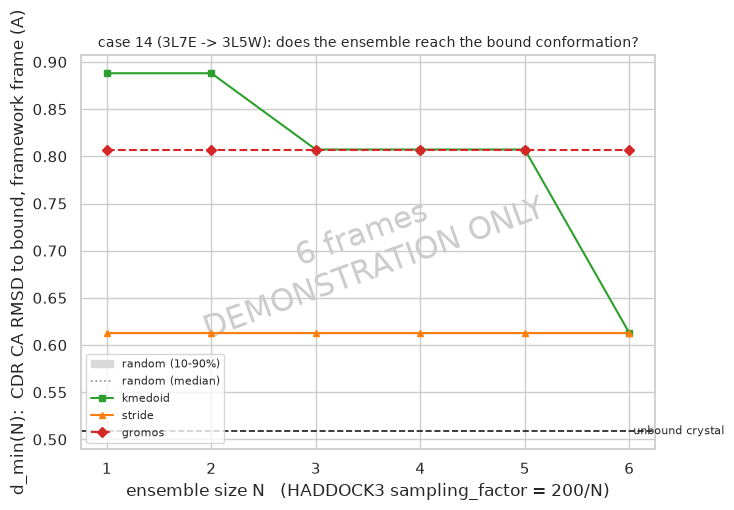

In [10]:
d_frames = ae.cdr_rmsd_to_bound(u, reference)
d_gromos = ae.score_pdb_models(GROMOS_CLUSTERS, reference)
print(f'CDR CA RMSD to bound, per trajectory frame: {np.round(d_frames, 3)}')
print(f'  best frame {d_frames.min():.3f} A, worst {d_frames.max():.3f} A, '
      f'mean {d_frames.mean():.3f} A')
print(f'unbound crystal                           : {d_unbound:.3f} A')
print(f'gromos/Loop_CA representatives ({len(d_gromos)})        : {np.round(d_gromos, 3)}')

curves = {name: ae.coverage_curve(d_frames, fn(N_MAX), N_MAX) for name, fn in strategies.items()}
curves['gromos'] = np.array([np.minimum.accumulate(d_gromos)[min(i, len(d_gromos) - 1)]
                             for i in range(N_MAX)])
rand = np.array([ae.coverage_curve(d_frames, ae.select_random(n_frames, N_MAX, rng), N_MAX)
                 for _ in range(N_RANDOM_REPEATS)])

cov = pd.DataFrame(curves, index=pd.RangeIndex(1, N_MAX + 1, name='N'))
cov['random_median'] = np.median(rand, axis=0)
cov.to_csv(RES / f'coverage_case{CASE}.csv')
display(cov.round(3))

fig, ax = plt.subplots(figsize=(7.5, 5))
N = np.arange(1, N_MAX + 1)
ax.fill_between(N, np.percentile(rand, 10, axis=0), np.percentile(rand, 90, axis=0),
                color='0.85', label='random (10-90%)')
ax.plot(N, np.median(rand, axis=0), color='0.55', lw=1.2, ls=':', label='random (median)')
styles = {'pcca': ('tab:blue', '-o'), 'kmedoid': ('tab:green', '-s'),
          'stride': ('tab:orange', '-^'), 'gromos': ('tab:red', '--D')}
for name, curve in curves.items():
    colour, style = styles.get(name, ('k', '-x'))
    ax.plot(N, curve, style, color=colour, label=name, ms=5)
ax.axhline(d_unbound, color='k', lw=1.2, ls='--')
ax.text(N_MAX, d_unbound, ' unbound crystal', va='center', fontsize=8)
ax.set_xlabel('ensemble size N   (HADDOCK3 sampling_factor = 200/N)')
ax.set_ylabel('d_min(N):  CDR CA RMSD to bound, framework frame (A)')
ax.set_title(f'case {CASE} ({ctx["unb_code"]} -> {ctx["ref_code"]}): does the ensemble reach the '
             f'bound conformation?', fontsize=10)
ax.legend(fontsize=8)
if not MEANINGFUL:
    ax.text(0.5, 0.5, f'{n_frames} frames\nDEMONSTRATION ONLY', transform=ax.transAxes,
            ha='center', va='center', fontsize=22, color='0.8', rotation=20, zorder=0)
fig.tight_layout()
fig.savefig(FIG / f'coverage_case{CASE}.png', dpi=150)
plt.show()

print(f'\nbest any strategy achieves at N={N_MAX}: '
      f'{min(c[-1] for c in curves.values()):.3f} A vs {d_unbound:.3f} A for the crystal alone')
if min(c[-1] for c in curves.values()) > d_unbound:
    print('-> no selection from this trajectory improves on the unbound crystal structure.')
    print('   With 6 frames spanning 12 ps that is the expected result: the sampling has not')
    print('   moved anywhere, so there is nothing better to select. This is the coverage')
    print('   question answered in the negative, not a failure of the selection method.')

## 6. Is the bound conformation inside the sampled region at all?

The diagnostic that matters more than the ranking. Both crystal structures are projected into the
**same** TIC space as the trajectory -- possible because the features are internal coordinates
measured identically on both, which check 1 verified to 1e-14 deg.

Three outcomes, with three different responses:

* the bound projection sits **inside** the sampled cloud -> selection is the whole problem, and
  the scoreboard above says which method solves it;
* it sits **outside, along a sampled direction** -> the simulation is going the right way and
  needs longer, or a bias along that direction;
* it sits **off every sampled direction** -> no amount of selecting or extending this trajectory
  will reach it, and the sampling protocol itself has to change.

Distances are quoted in TIC units, where a unit is one standard deviation of the slow mode, so
"the bound structure is 4 TIC-1 units away" means the trajectory never came within four typical
fluctuations of it along the slowest coordinate.

projection into the trajectory TIC space (units of the sampled standard deviation)
  TIC1: sampled [-1.00, +1.00]  bound -0.03  unbound +0.23  -> bound is -0.0 sd from the mean
  TIC2: sampled [-1.14, +0.93]  bound -0.56  unbound -0.22  -> bound is -0.4 sd from the mean

bound projection inside the sampled range on every TIC: True
nearest frame in TIC space: 3 (its CDR RMSD to bound is 0.888 A, best available is 0.613 A at frame 0)


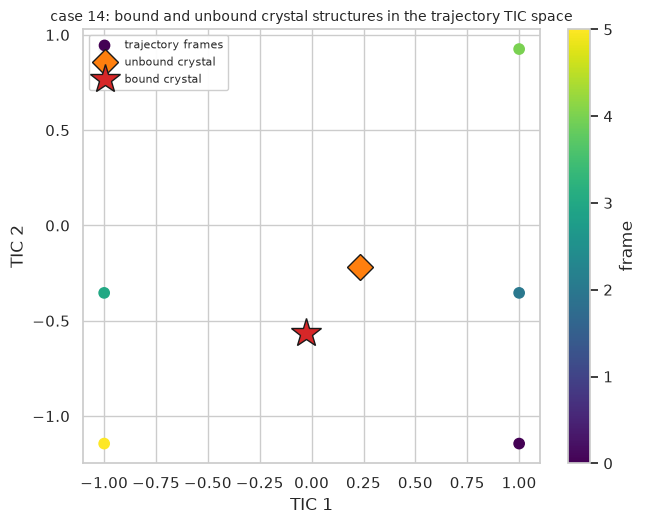

In [12]:
Y_bound = tica_model.transform(ae.sincos(A_bound))
Y_unbound = tica_model.transform(ae.sincos(A_unbound))
scale = Y.std(axis=0)
scale[scale == 0] = 1.0

gap_bound = (Y_bound[0] - Y.mean(axis=0)) / scale
inside = ((Y_bound[0] >= Y.min(axis=0)) & (Y_bound[0] <= Y.max(axis=0))).all()
nearest = int(np.argmin(np.linalg.norm(Y - Y_bound[0], axis=1)))

print('projection into the trajectory TIC space (units of the sampled standard deviation)')
for i in range(Y.shape[1]):
    lo, hi = Y[:, i].min(), Y[:, i].max()
    print(f'  TIC{i + 1}: sampled [{lo:+.2f}, {hi:+.2f}]  bound {Y_bound[0, i]:+.2f}  '
          f'unbound {Y_unbound[0, i]:+.2f}  -> bound is {gap_bound[i]:+.1f} sd from the mean')
print(f'\nbound projection inside the sampled range on every TIC: {inside}')
print(f'nearest frame in TIC space: {nearest} '
      f'(its CDR RMSD to bound is {d_frames[nearest]:.3f} A, '
      f'best available is {d_frames.min():.3f} A at frame {int(np.argmin(d_frames))})')

fig, ax = plt.subplots(figsize=(6.8, 5.4))
if Y.shape[1] >= 2:
    sc = ax.scatter(Y[:, 0], Y[:, 1], c=np.arange(n_frames), cmap='viridis', s=55,
                    label='trajectory frames', zorder=2)
    plt.colorbar(sc, ax=ax, label='frame')
    ax.plot(*Y_unbound[0, :2], 'D', color='tab:orange', ms=13, mec='k', label='unbound crystal',
            zorder=3)
    ax.plot(*Y_bound[0, :2], '*', color='tab:red', ms=22, mec='k', label='bound crystal', zorder=3)
    ax.set_xlabel('TIC 1')
    ax.set_ylabel('TIC 2')
else:
    ax.plot(Y[:, 0], np.zeros(n_frames), 'o', label='trajectory frames')
    ax.axvline(Y_bound[0, 0], color='tab:red', label='bound crystal')
    ax.set_xlabel('TIC 1')
ax.set_title(f'case {CASE}: bound and unbound crystal structures in the trajectory TIC space',
             fontsize=10)
ax.legend(fontsize=8, loc='upper left', framealpha=0.95)   # never over the data: its sample
fig.tight_layout()                                         # markers read as extra points
fig.savefig(FIG / f'tic_projection_case{CASE}.png', dpi=150)
plt.show()

## 7. Writing the ensemble for HADDOCK3

The selected frames go out as a multi-model PDB, which is what a `molecules` entry accepts. Two
details of how HADDOCK3 spends its budget shape this:

* `sampling_factor = int(sampling / len(models_to_dock))` -- the split is **even**, so with
  `sampling = 200` an 8-member ensemble gets 25 orientations each. If duplication pushes the model
  count past `sampling`, `sampling_factor` truncates to 0 and the run has nothing to do; the
  writer caps the count for that reason.
* There is **no per-member weight**. So a population-weighted ensemble is built by *duplicating*
  members: a state with twice the stationary probability appears twice, and the even split then
  approximates the weighting. Whether that is a good idea is a separate experiment -- it trades
  breadth for emphasis on the populated states -- so both versions are written.

In [13]:
HADDOCK_SAMPLING = 200      # [rigidbody] sampling in haddock_config.cfg
BEST = 'pcca' if 'pcca' in strategies else 'kmedoid'

chosen = strategies[BEST](N_MAX)
plain = ae.write_ensemble(u, chosen, RES / f'ensemble_case{CASE}_{BEST}.pdb')
print(f'strategy {BEST}: {plain["n_models"]} models -> {plain["path"]}')
print(f'  sampling_factor would be int({HADDOCK_SAMPLING}/{plain["n_models"]}) = '
      f'{HADDOCK_SAMPLING // plain["n_models"]} orientations per conformer')

if 'error' not in macro:
    pops = macro['populations'][np.argsort(-macro['populations'])][:len(chosen)]
    weighted = ae.write_ensemble(u, chosen, RES / f'ensemble_case{CASE}_{BEST}_weighted.pdb',
                                 weights=pops, total_sampling=HADDOCK_SAMPLING)
    print(f'population-weighted: copies {weighted["copies"]} -> {weighted["n_models"]} models, '
          f'sampling_factor {weighted["sampling_factor"]}')
else:
    print('population weighting skipped: no MSM, so no populations to weight by')

pd.DataFrame({'frame': chosen, 'cdr_rmsd_to_bound': d_frames[chosen]}).to_csv(
    RES / f'selection_case{CASE}_{BEST}.csv', index=False)
print(f'\nto use it, point the antibody entry of haddock_config.cfg at that file:')
print(f'  molecules = ["{Path(plain["path"]).name}", "antigen.pdb"]')

strategy kmedoid: 6 models -> data/ensemble/results/ensemble_case14_kmedoid.pdb
  sampling_factor would be int(200/6) = 33 orientations per conformer
population weighting skipped: no MSM, so no populations to weight by

to use it, point the antibody entry of haddock_config.cfg at that file:
  molecules = ["ensemble_case14_kmedoid.pdb", "antigen.pdb"]


## 8. Findings

### What is established

* **The pipeline is correct.** On a synthetic system with three states by construction, TICA finds
  the two slow modes (timescales 314 and 90 frames), PCCA+ recovers the states at **purity 1.000**,
  the stationary populations match the true frequencies (0.059/0.419/0.522 against
  0.066/0.468/0.466), and the selection returns one frame from each of the three.
* **TICA earns its place over dPCA.** On the same features, variance-based dPCA picks only **2 of
  3** states, because 40 of the 44 synthetic angles are fast nuisance variance three times wider
  than the slow signal. That is the situation a CDR loop is in, and it is the argument against
  clustering on any variance- or RMSD-based measure, `Loop_CA` included.
* **The three notebooks agree exactly where they overlap.** The crystal featurisation reproduces
  `ab_torsions_imgt.csv` for all 140 torsions to 3e-14 deg, and the coverage metric reproduces
  `ab_rmsds.ipynb`'s `cdr_ca_fw_rmsd` for the unbound structure to four decimals (0.5089 A both
  ways). The scoreboard is therefore on the same scale as the RMSD notebook's numbers.
* **The features are the ones the crystal analysis said matter**: 96 CDR backbone torsions plus 44
  interface `chi1`, 11 of which are framework residues that C-alpha loop clustering cannot see at
  all.

### What the test trajectory shows -- and it is not nothing

With 6 frames over 12 ps, every kinetic quantity is degenerate exactly as predicted: TICA reports
a 1e15-frame timescale (rank-deficient covariance, an eigenvalue numerically at 1), and the MSM
fails outright with a constant second eigenvector. Both are the arithmetic refusing to estimate,
and both are reported rather than smoothed over.

The *geometric* part of the scoreboard still works, and it says something useful:

| conformer source | CDR C-alpha RMSD to bound (A) |
|---|---|
| unbound crystal structure | **0.509** |
| best of the 6 MD frames | 0.613 |
| gromos / `Loop_CA` representative | 0.807 |
| mean over MD frames | 0.816 |

**Every MD frame is further from the bound conformation than the unbound crystal structure it
started from.** For a 12 ps run that is the expected and reassuring result -- the trajectory is
still relaxing away from the crystal and has sampled nothing new -- but it is worth stating
plainly, because it means *the current CDR ensemble makes this case worse, not better*. It also
sets the bar for the production run: an ensemble is only worth docking if `d_min(N)` drops below
the horizontal line at 0.509 A.

Note also that the gromos representative (0.807 A) is not the best available frame (0.613 A). With
one cluster that is inevitable, but it is the pattern to watch for at scale: a medoid is the centre
of an RMSD neighbourhood, and the centre is not the member closest to the target.

### When the production trajectories land

Nothing here needs rewriting. In order:

1. Set `TRAJ`, then read `LAG` off the implied-timescale plateau in section 3 instead of taking the
   longest scanned lag.
2. Set `N_MACRO` from the timescale gap in section 4 -- that is the number this whole approach
   substitutes for the indefensible RMSD cutoff.
3. Read section 5 for the answer: does `d_min(N)` beat 0.509 A, does `pcca` beat `kmedoid` (i.e.
   does the kinetic part contribute beyond the TICA coordinates), and do either beat `random`. If
   `random` is competitive, the machinery is not paying for itself on this system and the honest
   move is to say so.
4. Read section 6 first if section 5 disappoints. If the bound projection is outside the sampled
   TIC range, the selection method is irrelevant and the sampling protocol is the problem.
5. Then, and only then, the ensemble-size question: `sampling_factor = int(200/N)`, so compare
   docking runs at fixed total budget rather than fixed `N`.

### Caveats

* `d_min(N)` scores conformational coverage, not docking success. It is a necessary condition --
  an ensemble that never approaches the bound loop conformation cannot dock it correctly -- but
  the sufficient test is `caprieval` output, which needs the docking runs themselves.
* The metric superposes on the Fv framework, so it is blind to a VH/VL packing change, exactly as
  `ab_rmsds.ipynb`'s `fv_fw_ca` scheme is.
* Populations from the AWH trajectory are not Boltzmann. Build the state decomposition on the free
  MD; reweight with `gmx awh` output before believing any population that came from the biased run.
* One case. `ab_torsions.ipynb` identified 3HI5 and 3V6F as the two genuinely CDR-H3-flexible
  cases in the benchmark; those are where an ensemble has the most room to help, and they are the
  ones worth running this on first.